# jaxpensive: Group Sequential Testing Demo

A demonstration of `CanonicalBounds` — stopping boundaries for clinical trials and experiments with planned interim analyses.

## What is group sequential testing?

In a standard hypothesis test you look at data once at the end of a study. In a **group sequential trial** you plan multiple interim analyses ("looks") and stop early if the evidence is strong enough.

The challenge: looking multiple times inflates your type I error rate. Using α=0.05 independently at each look would give an overall false positive rate well above 5%.

**Group sequential bounds** solve this by setting tighter thresholds at early looks, calibrated so the cumulative type I error across all looks equals exactly α.

Key parameters:

| Parameter | API arg | Meaning |
|-----------|---------|---------|
| K | `reads` | Number of planned interim looks |
| α | `alpha` | Overall type I error rate (e.g. 0.05) |
| Sides | `sides` | 1 = one-sided test, 2 = two-sided |
| Method | `method` | Boundary shape: `'obrien_fleming'` or `'pocock'` |

## The mechanics

### Test statistics are z-scores — but correlated ones

At each look $k$, we compute a test statistic $Z_k$. Under the null hypothesis, $Z_k \sim \mathcal{N}(0, 1)$ marginally — an ordinary z-score.

But the $Z_k$ are **not independent**. Each look accumulates all the data seen so far, so $Z_2$ overlaps with $Z_1$, $Z_3$ overlaps with $Z_1$ and $Z_2$, and so on. This shared data induces correlation.

### The covariance structure

The information fraction at look $k$ is $t_k = k/K$ (for equally spaced looks). The covariance between $Z_i$ and $Z_j$ follows directly from the Brownian motion property of sequential statistics:

$$\text{Cov}(Z_i, Z_j) = \sqrt{\frac{\min(t_i,\, t_j)}{\max(t_i,\, t_j)}}$$

So the vector $(Z_1, \ldots, Z_K)$ is jointly multivariate normal:

$$(Z_1, \ldots, Z_K) \sim \mathcal{N}(\mathbf{0},\, \Sigma) \quad \text{where} \quad \Sigma_{ij} = \sqrt{\frac{\min(t_i, t_j)}{\max(t_i, t_j)}}$$

Early looks are highly correlated with later ones; the matrix is dense and fully determined by the information fractions alone.

### Solving for the critical value

For a given boundary shape (O'Brien-Fleming or Pocock), the boundaries at each look are a deterministic function of a single critical value $c$. We find $c$ by solving:

$$P(Z_1 \leq b_1(c),\ Z_2 \leq b_2(c),\ \ldots,\ Z_K \leq b_K(c)) = 1 - \alpha/2$$

The left-hand side is the multivariate normal CDF evaluated at $(b_1, \ldots, b_K)$. We use `scipy.stats.multivariate_normal.cdf` to compute it and `scipy.optimize.brentq` (Brent's method) to find the $c$ that makes the equation hold.

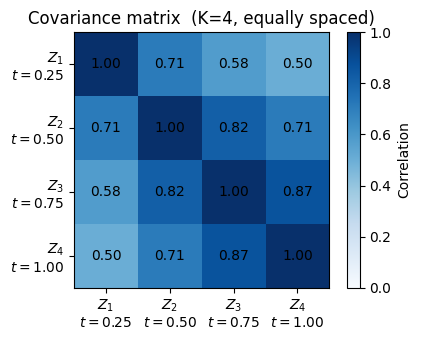

Covariance matrix Σ:
[[1.     0.7071 0.5774 0.5   ]
 [0.7071 1.     0.8165 0.7071]
 [0.5774 0.8165 1.     0.866 ]
 [0.5    0.7071 0.866  1.    ]]


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from jaxpensive import CanonicalBounds

# Show the covariance matrix for K=4 equally-spaced looks
K = 4
t = np.array([k / K for k in range(1, K + 1)])
cov = np.sqrt(np.minimum.outer(t, t) / np.maximum.outer(t, t))

fig, ax = plt.subplots(figsize=(4.5, 3.5))
im = ax.imshow(cov, vmin=0, vmax=1, cmap="Blues")
fig.colorbar(im, ax=ax, label="Correlation")

labels = [f"$Z_{k}$\n$t={t[k-1]:.2f}$" for k in range(1, K + 1)]
ax.set_xticks(range(K)); ax.set_xticklabels(labels)
ax.set_yticks(range(K)); ax.set_yticklabels(labels)

for i in range(K):
    for j in range(K):
        ax.text(j, i, f"{cov[i, j]:.2f}", ha="center", va="center", fontsize=10)

ax.set_title(f"Covariance matrix  (K={K}, equally spaced)")
plt.tight_layout()
plt.show()

print("Covariance matrix Σ:")
print(np.round(cov, 4))

## Basic Usage

Construct a `CanonicalBounds` object and call `summary()` to see the stopping boundaries at each look.

In [2]:
bounds = CanonicalBounds(reads=4, alpha=0.05, sides=2, method="obrien_fleming")
bounds.summary()


Group Sequential Bounds — obrien_fleming
  Looks : 4
  Alpha : 0.05
  Sides : 2
  ----------------------------------
  Look   Info fraction  Boundary (z)
  ----------------------------------
     1          0.2500        4.0486
     2          0.5000        2.8628
     3          0.7500        2.3375
     4          1.0000        2.0243
  ----------------------------------


## O'Brien-Fleming Bounds

O'Brien-Fleming boundaries are **conservative early and liberal late**. The critical value at look k is `c / √(t_k)`, so early looks demand very strong evidence. This preserves most of the study's power and is the most widely used boundary in practice.

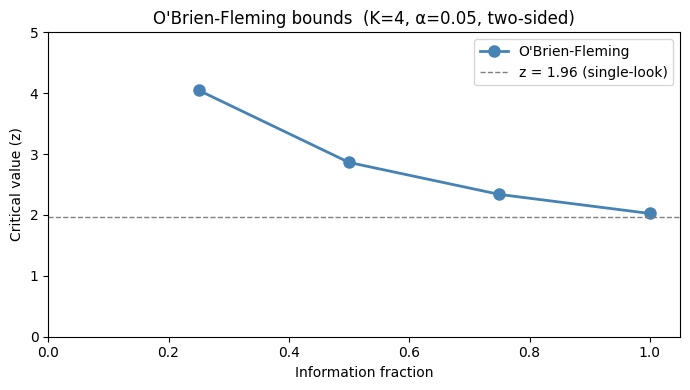

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

b_obj = CanonicalBounds(reads=4, alpha=0.05, sides=2, method="obrien_fleming")
t = b_obj.info_fractions
b = b_obj.calculate_bounds()

ax.plot(t, b, "o-", color="steelblue", linewidth=2, markersize=8, label="O'Brien-Fleming")
ax.axhline(1.96, linestyle="--", color="gray", linewidth=1, label="z = 1.96 (single-look)")

ax.set_xlabel("Information fraction")
ax.set_ylabel("Critical value (z)")
ax.set_title("O'Brien-Fleming bounds  (K=4, α=0.05, two-sided)")
ax.legend()
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 5)
plt.tight_layout()
plt.show()

## Pocock Bounds

Pocock boundaries are **constant across all looks** — the same critical value at every interim analysis. This is easy to communicate to investigators but spends alpha more aggressively early, leaving less power at the final look.

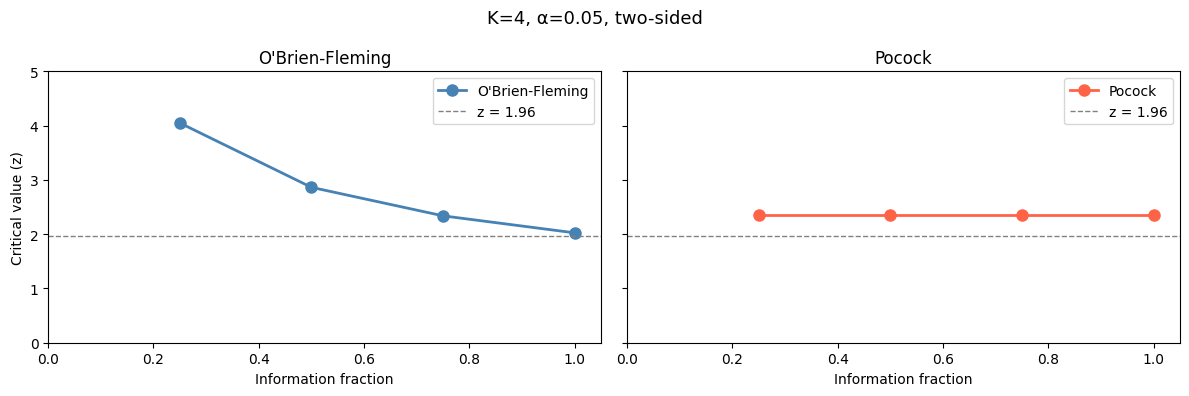

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, method, color, title in zip(
    axes,
    ["obrien_fleming", "pocock"],
    ["steelblue", "tomato"],
    ["O'Brien-Fleming", "Pocock"],
):
    b_obj = CanonicalBounds(reads=4, alpha=0.05, sides=2, method=method)
    t = b_obj.info_fractions
    b = b_obj.calculate_bounds()
    ax.plot(t, b, "o-", color=color, linewidth=2, markersize=8, label=title)
    ax.axhline(1.96, linestyle="--", color="gray", linewidth=1, label="z = 1.96")
    ax.set_title(title)
    ax.set_xlabel("Information fraction")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 5)
    ax.legend()

axes[0].set_ylabel("Critical value (z)")
fig.suptitle("K=4, α=0.05, two-sided", fontsize=13)
plt.tight_layout()
plt.show()

## Effect of Varying K

More planned looks means the alpha budget is spread thinner, tightening each individual boundary. Here we compare O'Brien-Fleming bounds for K = 2, 4, 6, and 8 looks.

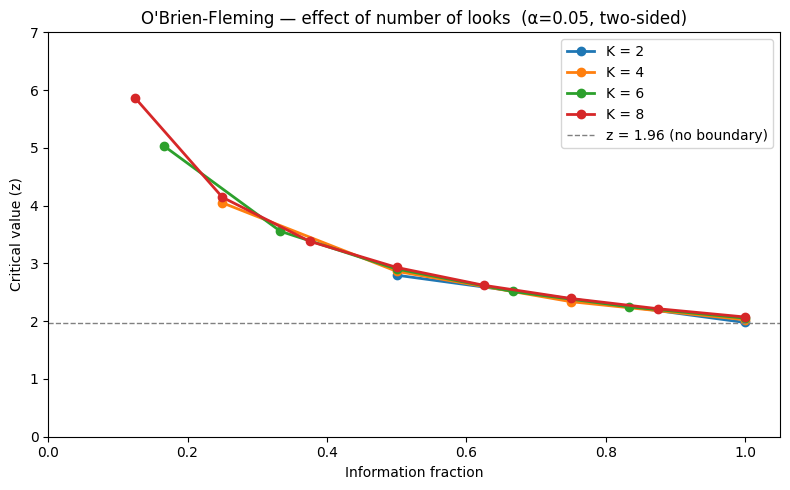

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for k, color in zip([2, 4, 6, 8], colors):
    b_obj = CanonicalBounds(reads=k, alpha=0.05, sides=2, method="obrien_fleming")
    t = b_obj.info_fractions
    b = b_obj.calculate_bounds()
    ax.plot(t, b, "o-", color=color, linewidth=2, markersize=6, label=f"K = {k}")

ax.axhline(1.96, linestyle="--", color="gray", linewidth=1, label="z = 1.96 (no boundary)")
ax.set_xlabel("Information fraction")
ax.set_ylabel("Critical value (z)")
ax.set_title("O'Brien-Fleming — effect of number of looks  (α=0.05, two-sided)")
ax.legend()
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 7)
plt.tight_layout()
plt.show()